# Large corpus

#### Distil_XLSR_5_Custom_Trans_Layer_VIB_noaudioaug_randomstart_large_corpus_on_2s_best124_eval_largecopus

EER: 0.21288768817813 at threshold: -0.3852575719356537
Max score: 3.868873834609986 - Min score: -3.3653159141540527
####False Postive
InWild - 17 - 0.3610%
Elevenlabs - 3 - 0.1440%
Tortoise-TTS - 12 - 0.5057%
VITS-TTS - 6 - 0.3715%
DDDM-VC - 2 - 0.2577%
AIHUB - 6 - 0.0627%
VITS-VC - 0 - 0.0000%
SeamlessM4T-TTS - 0 - 0.0000%
StarGANv2-VC - 0 - 0.0000%
OpenVoice - 0 - 0.0000%
Diff-HierVC - 0 - 0.0000%
StyleTTS2 - 0 - 0.0000%
MeloTTS - 1 - 0.2415%
MMSTTS - 1 - 0.1379%
DiffGAN - 0 - 0.0000%
SNS2024 - 2 - 0.3378%
ASVspoof2019 - 1 - 0.0103%
LibriSpeech - 0 - 0.0000%
VCTK - 0 - 0.0000%
LJSpeech - 0 - 0.0000%
CommonVoice - 0 - 0.0000%
####False negative
InWild - 0 - 0.0000%
Elevenlabs - 0 - 0.0000%
Tortoise-TTS - 0 - 0.0000%
VITS-TTS - 0 - 0.0000%
DDDM-VC - 0 - 0.0000%
AIHUB - 27 - 0.2820%
VITS-VC - 0 - 0.0000%
SeamlessM4T-TTS - 0 - 0.0000%
StarGANv2-VC - 0 - 0.0000%
OpenVoice - 0 - 0.0000%
Diff-HierVC - 0 - 0.0000%
StyleTTS2 - 0 - 0.0000%
MeloTTS - 0 - 0.0000%
MMSTTS - 0 - 0.0000%
DiffGAN -

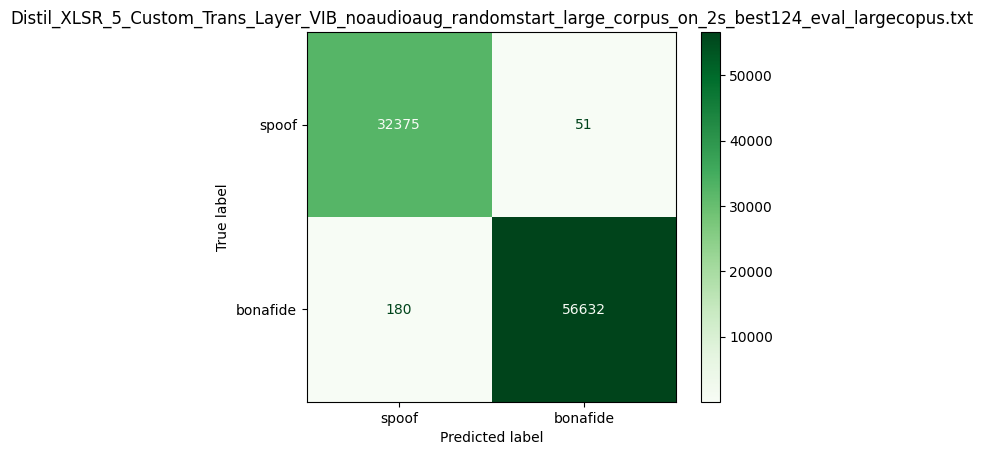

In [49]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt
# Read the predictions DataFrame
pred_df = pd.read_csv("results/Distil_XLSR_5_Custom_Trans_Layer_VIB_noaudioaug_randomstart_large_corpus_on_2s_best124_eval_largecopus.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])
# Read the metadata DataFrame
metadata_df = pd.read_csv("/datab/Dataset/cnsl_real_fake_audio/0_large-corpus/meta_may27.csv")

# Filter the metadata to keep only 'eval' subset
metadata_df = metadata_df[metadata_df['subset'] == 'eval']


metadata_df.rename(columns={"path": "utt_id"}, inplace=True)

merged_df = pd.merge(metadata_df, pred_df, on="utt_id", how="inner")


bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, th = em.compute_eer(bona_cm, spoof_cm)

print(f"EER: {eer_cm*100} at threshold: {th}")
print(f"Max score: {max_score} - Min score: {min_score}")

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

filter = 'group'
groups = merged_df[filter].unique()

print("####False Postive")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'spoof') & (merged_df['pred']=='bonafide') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    
print("####False negative")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'bonafide') & (merged_df['pred']=='spoof') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("Distil_XLSR_5_Custom_Trans_Layer_VIB_noaudioaug_randomstart_large_corpus_on_2s_best124_eval_largecopus.txt")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()


#### vib_conf-5_gelu_2s_may27_epoch6_eval_2s_intern 

EER: 0.1446405589491882 at threshold: -0.3760050237178802
Max score: 3.663342237472534 - Min score: -3.3211047649383545
####False Postive
InWild - 13 - 0.2761%
Elevenlabs - 3 - 0.1440%
Tortoise-TTS - 3 - 0.1264%
VITS-TTS - 4 - 0.2477%
DDDM-VC - 1 - 0.1289%
AIHUB - 0 - 0.0000%
VITS-VC - 0 - 0.0000%
SeamlessM4T-TTS - 0 - 0.0000%
StarGANv2-VC - 0 - 0.0000%
OpenVoice - 0 - 0.0000%
Diff-HierVC - 0 - 0.0000%
StyleTTS2 - 0 - 0.0000%
MeloTTS - 0 - 0.0000%
MMSTTS - 2 - 0.2759%
DiffGAN - 0 - 0.0000%
SNS2024 - 3 - 0.5068%
ASVspoof2019 - 2 - 0.0206%
LibriSpeech - 0 - 0.0000%
VCTK - 0 - 0.0000%
LJSpeech - 0 - 0.0000%
CommonVoice - 0 - 0.0000%
####False negative
InWild - 0 - 0.0000%
Elevenlabs - 0 - 0.0000%
Tortoise-TTS - 0 - 0.0000%
VITS-TTS - 0 - 0.0000%
DDDM-VC - 0 - 0.0000%
AIHUB - 32 - 0.3342%
VITS-VC - 0 - 0.0000%
SeamlessM4T-TTS - 0 - 0.0000%
StarGANv2-VC - 0 - 0.0000%
OpenVoice - 0 - 0.0000%
Diff-HierVC - 0 - 0.0000%
StyleTTS2 - 0 - 0.0000%
MeloTTS - 0 - 0.0000%
MMSTTS - 0 - 0.0000%
DiffGAN 

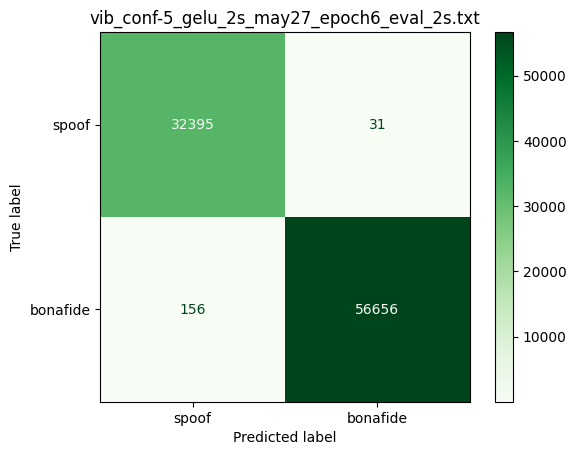

In [52]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt
# Read the predictions DataFrame
pred_df = pd.read_csv("results/vib_conf-5_gelu_2s_may27_epoch6_eval_2s.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])
# Read the metadata DataFrame
metadata_df = pd.read_csv("/datab/Dataset/cnsl_real_fake_audio/0_large-corpus/meta_may27.csv")

# Filter the metadata to keep only 'eval' subset
metadata_df = metadata_df[metadata_df['subset'] == 'eval']


metadata_df.rename(columns={"path": "utt_id"}, inplace=True)

merged_df = pd.merge(metadata_df, pred_df, on="utt_id", how="inner")


bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, th = em.compute_eer(bona_cm, spoof_cm)

print(f"EER: {eer_cm*100} at threshold: {th}")
print(f"Max score: {max_score} - Min score: {min_score}")

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

filter = 'group'
groups = merged_df[filter].unique()

print("####False Postive")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'spoof') & (merged_df['pred']=='bonafide') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    
print("####False negative")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'bonafide') & (merged_df['pred']=='spoof') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("vib_conf-5_gelu_2s_may27_epoch6_eval_2s.txt")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()


### /data/hungdx/asvspoof5/docs/dev_3_augall_wavlmbase_co_aasist_conv_res2net_seblock_sclnormal_6s_large-corpus_epoch_18.txt

EER: 0.9813716659388282 at threshold: -1.2726144790649414
Max score: 0.1675489395856857 - Min score: -2.067535877227783
####False Postive
InWild - 58 - 1.2317%
Tortoise-TTS - 58 - 2.4442%
VITS-TTS - 24 - 1.4861%
DDDM-VC - 2 - 0.2577%
AIHUB - 14 - 0.1462%
VITS-VC - 12 - 1.0076%
StarGANv2-VC - 0 - 0.0000%
Diff-HierVC - 0 - 0.0000%
StyleTTS2 - 26 - 4.4983%
MMSTTS - 3 - 0.4138%
DiffGAN - 2 - 1.0000%
ASVspoof2019 - 76 - 0.7842%
LibriSpeech - 0 - 0.0000%
VCTK - 0 - 0.0000%
LJSpeech - 0 - 0.0000%
CommonVoice - 0 - 0.0000%
####False negative
InWild - 0 - 0.0000%
Tortoise-TTS - 0 - 0.0000%
VITS-TTS - 0 - 0.0000%
DDDM-VC - 0 - 0.0000%
AIHUB - 2 - 0.0209%
VITS-VC - 0 - 0.0000%
StarGANv2-VC - 0 - 0.0000%
Diff-HierVC - 0 - 0.0000%
StyleTTS2 - 0 - 0.0000%
MMSTTS - 0 - 0.0000%
DiffGAN - 0 - 0.0000%
ASVspoof2019 - 0 - 0.0000%
LibriSpeech - 31 - 0.1176%
VCTK - 487 - 12.9728%
LJSpeech - 4 - 10.0000%
CommonVoice - 28 - 0.1362%
Accuracy: 99.0174%


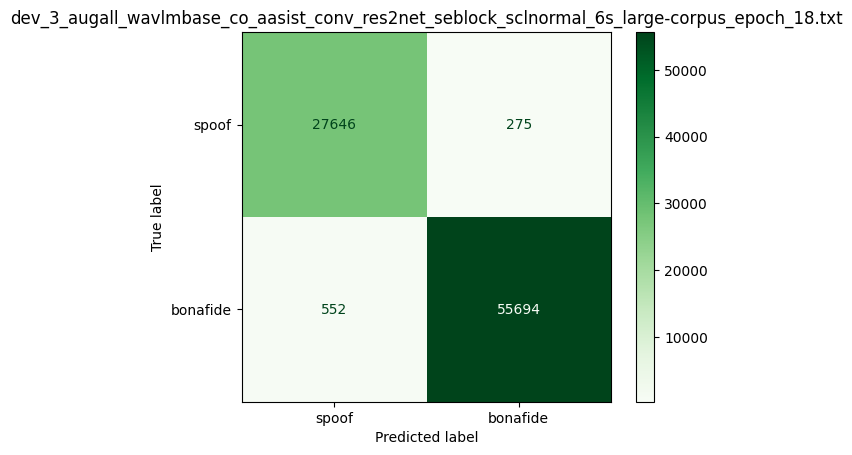

In [4]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt
# Read the predictions DataFrame
pred_df = pd.read_csv("/data/hungdx/asvspoof5/docs/dev_3_augall_wavlmbase_co_aasist_conv_res2net_seblock_sclnormal_6s_large-corpus_epoch_18.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "spoof", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])
# Read the metadata DataFrame
metadata_df = pd.read_csv("/datab/Dataset/cnsl_real_fake_audio/0_large-corpus/meta_may27.csv")

# Filter the metadata to keep only 'eval' subset
metadata_df = metadata_df[metadata_df['subset'] == 'eval']


metadata_df.rename(columns={"path": "utt_id"}, inplace=True)

merged_df = pd.merge(metadata_df, pred_df, on="utt_id", how="inner")


bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, threshold = em.compute_eer(bona_cm, spoof_cm)

print(f"EER: {eer_cm*100} at threshold: {th}")
print(f"Max score: {max_score} - Min score: {min_score}")

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

filter = 'group'
groups = merged_df[filter].unique()

print("####False Postive")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'spoof') & (merged_df['pred']=='bonafide') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    
print("####False negative")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'bonafide') & (merged_df['pred']=='spoof') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("dev_3_augall_wavlmbase_co_aasist_conv_res2net_seblock_sclnormal_6s_large-corpus_epoch_18.txt")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()


# Intern 2024

### Distil_XLSR_5_Custom_Trans_Layer_VIB_noaudioaug_randomstart_large_corpus_on_2s_best124_intern_2s

EER: 3.5527745644477164 at threshold: 1.6106587648391724
Max score: 3.720024347305298 - Min score: -3.3454606533050537
False Positive
www.youtube.com - 1 - 0.3003%
elevenlabs.io - 13 - 7.9268%
studio.neiro.ai - 1 - 14.2857%
www.facebook.com - 0 - 0.0000%
app.resemble.ai - 1 - 6.6667%
webapp.dubverse.ai - 0 - 0.0000%
grad-tts.github.io - 1 - 20.0000%
nbviewer.org - 0 - 0.0000%
styletts2.github.io - 0 - 0.0000%
jik876.github.io - 2 - 20.0000%
huggingface.co - 1 - 1.1494%
github.com - 0 - 0.0000%
voice.ai - 0 - 0.0000%
www.kecl.ntt.co.jp - 0 - 0.0000%
False negative
www.youtube.com - 8 - 2.4024%
elevenlabs.io - 0 - 0.0000%
studio.neiro.ai - 0 - 0.0000%
www.facebook.com - 0 - 0.0000%
app.resemble.ai - 0 - 0.0000%
webapp.dubverse.ai - 0 - 0.0000%
grad-tts.github.io - 0 - 0.0000%
nbviewer.org - 0 - 0.0000%
styletts2.github.io - 0 - 0.0000%
jik876.github.io - 0 - 0.0000%
huggingface.co - 0 - 0.0000%
github.com - 0 - 0.0000%
voice.ai - 0 - 0.0000%
www.kecl.ntt.co.jp - 0 - 0.0000%
Accuracy: 96.

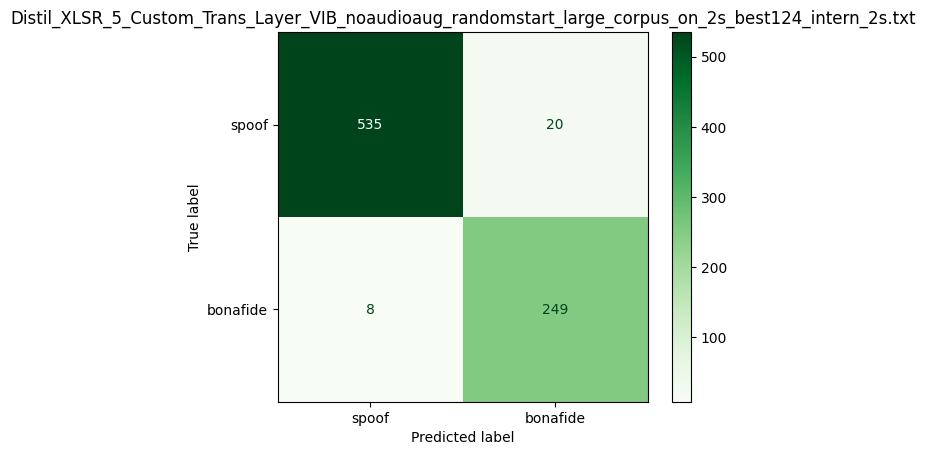

In [2]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt

intern24_df = pd.read_csv("/datab/Dataset/intern_2024_jan31/metadata_jan30.csv")
intern24_df.fillna("-", inplace=True)
intern24_df = intern24_df.astype(str)
# print(intern24_df.head)
intern24_df['source_group'] = intern24_df.apply(lambda x: x['Source link'].replace("//", "/").split("/")[1], axis=1)
intern24_df['source_group'] = intern24_df['source_group'].apply(lambda x: 'www.youtube.com' if (x == 'youtu.be' or x == 'youtube.com') else x)

intern24_df.rename(columns={"path": "utt_id"}, inplace=True)

intern24_df["utt_id"] = intern24_df["utt_id"].apply(lambda x: x.split("./")[1])


# Read the predictions DataFrame
pred_df = pd.read_csv("results/Distil_XLSR_5_Custom_Trans_Layer_VIB_noaudioaug_randomstart_large_corpus_on_2s_best124_intern_2s.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])

merged_df = pd.merge(intern24_df, pred_df, on="utt_id", how="inner")

bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, threshold = em.compute_eer(bona_cm, spoof_cm)

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

print(f"EER: {eer_cm*100} at threshold: {threshold}")
print(f"Max score: {max_score} - Min score: {min_score}")


filter = 'source_group'
print("False Positive")
groups = merged_df[filter].unique()
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'spoof') & (merged_df['pred']=='bonafide') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    
print("False negative")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'bonafide') & (merged_df['pred']=='spoof') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("Distil_XLSR_5_Custom_Trans_Layer_VIB_noaudioaug_randomstart_large_corpus_on_2s_best124_intern_2s.txt")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()

### vib_conf-5_gelu_2s_may27_epoch6_eval_2s_intern.txt

EER: 2.713219055631507 at threshold: 0.4549778401851654
Max score: 3.637438058853149 - Min score: -3.3132007122039795
False Positive
www.youtube.com - 4 - 1.2012%
elevenlabs.io - 9 - 5.4878%
studio.neiro.ai - 0 - 0.0000%
www.facebook.com - 0 - 0.0000%
app.resemble.ai - 0 - 0.0000%
webapp.dubverse.ai - 0 - 0.0000%
grad-tts.github.io - 1 - 20.0000%
nbviewer.org - 0 - 0.0000%
styletts2.github.io - 0 - 0.0000%
jik876.github.io - 1 - 10.0000%
huggingface.co - 1 - 1.1494%
github.com - 0 - 0.0000%
voice.ai - 0 - 0.0000%
www.kecl.ntt.co.jp - 0 - 0.0000%
False negative
www.youtube.com - 7 - 2.1021%
elevenlabs.io - 0 - 0.0000%
studio.neiro.ai - 0 - 0.0000%
www.facebook.com - 0 - 0.0000%
app.resemble.ai - 0 - 0.0000%
webapp.dubverse.ai - 0 - 0.0000%
grad-tts.github.io - 0 - 0.0000%
nbviewer.org - 0 - 0.0000%
styletts2.github.io - 0 - 0.0000%
jik876.github.io - 0 - 0.0000%
huggingface.co - 0 - 0.0000%
github.com - 0 - 0.0000%
voice.ai - 0 - 0.0000%
www.kecl.ntt.co.jp - 0 - 0.0000%
Accuracy: 97.167

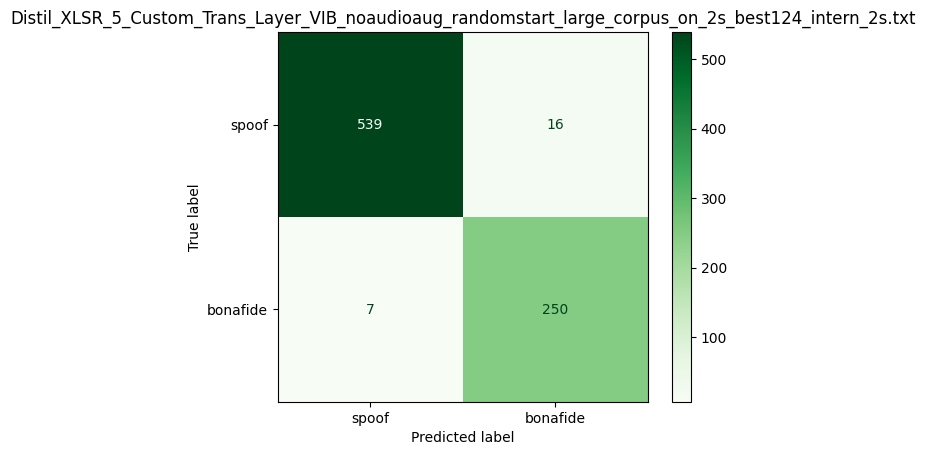

In [4]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt

intern24_df = pd.read_csv("/datab/Dataset/intern_2024_jan31/metadata_jan30.csv")
intern24_df.fillna("-", inplace=True)
intern24_df = intern24_df.astype(str)
# print(intern24_df.head)
intern24_df['source_group'] = intern24_df.apply(lambda x: x['Source link'].replace("//", "/").split("/")[1], axis=1)
intern24_df['source_group'] = intern24_df['source_group'].apply(lambda x: 'www.youtube.com' if (x == 'youtu.be' or x == 'youtube.com') else x)

intern24_df.rename(columns={"path": "utt_id"}, inplace=True)

intern24_df["utt_id"] = intern24_df["utt_id"].apply(lambda x: x.split("./")[1])


# Read the predictions DataFrame
pred_df = pd.read_csv("results/vib_conf-5_gelu_2s_may27_epoch6_eval_2s_intern.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])

merged_df = pd.merge(intern24_df, pred_df, on="utt_id", how="inner")

bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, threshold = em.compute_eer(bona_cm, spoof_cm)

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

print(f"EER: {eer_cm*100} at threshold: {threshold}")
print(f"Max score: {max_score} - Min score: {min_score}")


filter = 'source_group'
print("False Positive")
groups = merged_df[filter].unique()
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'spoof') & (merged_df['pred']=='bonafide') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    
print("False negative")
for group in groups:
    num_misclass = merged_df[(merged_df['label'] == 'bonafide') & (merged_df['pred']=='spoof') & (merged_df[filter]==group)].shape[0]
    num_total = merged_df[merged_df[filter]==group].shape[0]
    print("{} - {} - {:.4f}%".format(group, num_misclass, num_misclass/num_total*100))
    

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
disp.plot(cmap='Greens', values_format='g')
plt.title("Distil_XLSR_5_Custom_Trans_Layer_VIB_noaudioaug_randomstart_large_corpus_on_2s_best124_intern_2s.txt")
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()

# ASVSpoof5

#### best Conformer

EER: 3.5036594950536792 at threshold: -3.9268760681152335
Max score: 5.428022861480713 - Min score: -5.650076866149902
Accuracy: 93.8241%


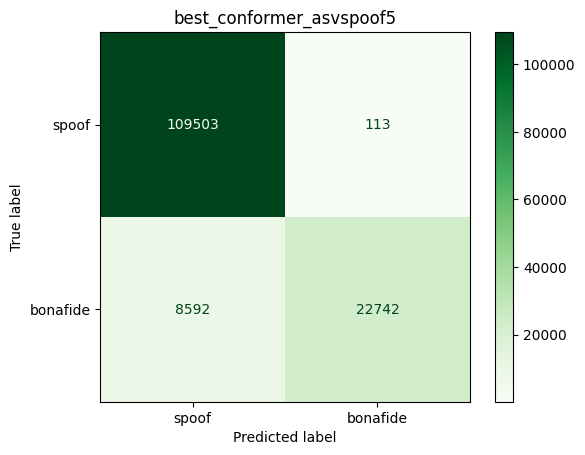

In [13]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt
# Read the predictions DataFrame
pred_df = pd.read_csv("/data/hungdx/Towards-Real-Time-Deepfake-Speech-Detection-in-Resource-Limited-Scenarios/runs/asvspoof5/ConformerModel_baseline_score.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])
# Read the metadata DataFrame
metadata_df = pd.read_csv("/data/hungdx/asvspoof5/DATA/ASVspoof5/protocol.txt", sep=" ", header=None)
metadata_df.columns = ["utt_id", "subset", "label"]

# Filter the metadata to keep only 'eval' subset
# metadata_df = metadata_df[metadata_df['subset'] == 'eval']


merged_df = pd.merge(metadata_df, pred_df, on="utt_id", how="inner")


merged_df = merged_df[merged_df['subset'] == 'dev']


bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, th = em.compute_eer(bona_cm, spoof_cm)

print(f"EER: {eer_cm*100} at threshold: {th}")
print(f"Max score: {max_score} - Min score: {min_score}")

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("best_conformer_asvspoof5")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()


#### best aasist

EER: 3.165743175382086 at threshold: -2.975529193878174
Max score: 4.233048439025879 - Min score: -3.187772035598755
Accuracy: 89.2941%


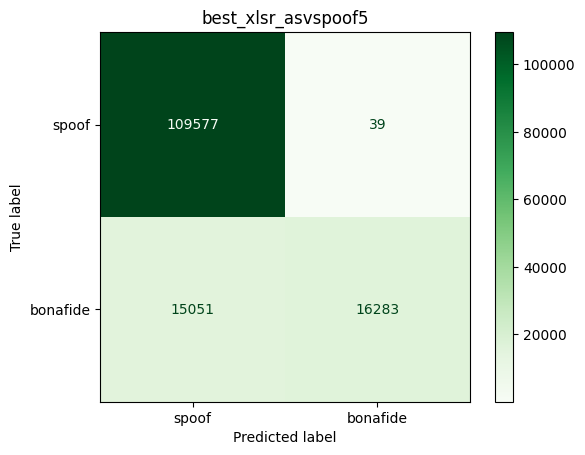

In [15]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt
# Read the predictions DataFrame
pred_df = pd.read_csv("/data/hungdx/Towards-Real-Time-Deepfake-Speech-Detection-in-Resource-Limited-Scenarios/runs/asvspoof5/XLSR_AASIST_baseline_score.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])
# Read the metadata DataFrame
metadata_df = pd.read_csv("/data/hungdx/asvspoof5/DATA/ASVspoof5/protocol.txt", sep=" ", header=None)
metadata_df.columns = ["utt_id", "subset", "label"]

# Filter the metadata to keep only 'eval' subset
# metadata_df = metadata_df[metadata_df['subset'] == 'eval']


merged_df = pd.merge(metadata_df, pred_df, on="utt_id", how="inner")


merged_df = merged_df[merged_df['subset'] == 'dev']


bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, th = em.compute_eer(bona_cm, spoof_cm)

print(f"EER: {eer_cm*100} at threshold: {th}")
print(f"Max score: {max_score} - Min score: {min_score}")

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("best_xlsr_asvspoof5")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()


#### Sinc-AASIST

EER: 45.294468671720104 at threshold: 0.0904955118894577
Max score: 0.0909085720777511 - Min score: 0.0861311629414558
Accuracy: 54.7078%


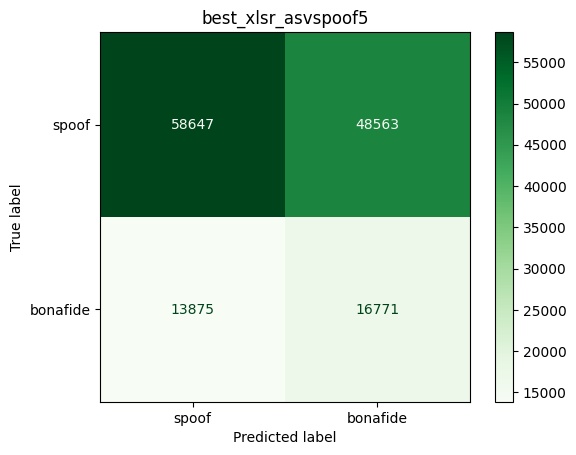

In [6]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt
# Read the predictions DataFrame
pred_df = pd.read_csv("/data/hungdx/asvspoof5/docs/dev_3_augall_sincconv_aasist_normal_asvspoof5_epoch_7.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "spoof", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])
# Read the metadata DataFrame
metadata_df = pd.read_csv("/data/hungdx/asvspoof5/DATA/ASVspoof5/protocol.txt", sep=" ", header=None)
metadata_df.columns = ["utt_id", "subset", "label"]

# Filter the metadata to keep only 'eval' subset
# metadata_df = metadata_df[metadata_df['subset'] == 'eval']


merged_df = pd.merge(metadata_df, pred_df, on="utt_id", how="inner")


merged_df = merged_df[merged_df['subset'] == 'dev']


bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, threshold = em.compute_eer(bona_cm, spoof_cm)

print(f"EER: {eer_cm*100} at threshold: {threshold}")
print(f"Max score: {max_score} - Min score: {min_score}")

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("best_xlsr_asvspoof5")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()


#### Conformer

EER: 26.00998697955013 at threshold: -2.704582691192627
Max score: -0.070996880531311 - Min score: -6.074739933013916
Accuracy: 73.9894%


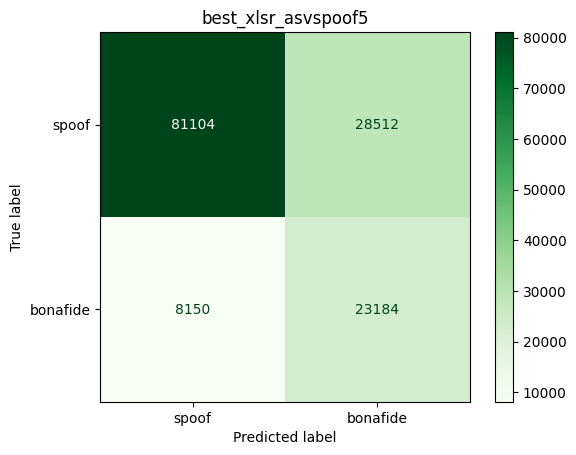

In [7]:
import pandas as pd
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, precision_score, det_curve
import matplotlib.pyplot as plt
# Read the predictions DataFrame
pred_df = pd.read_csv("/data/hungdx/asvspoof5/docs/dev_out_3_augall_rawnet3_conformermed_normal_epoch0.txt", sep=" ", header=None)
pred_df.columns = ["utt_id", "spoof", "score"]

pred_df = pred_df.drop_duplicates(subset=['utt_id'])
# Read the metadata DataFrame
metadata_df = pd.read_csv("/data/hungdx/asvspoof5/DATA/ASVspoof5/protocol.txt", sep=" ", header=None)
metadata_df.columns = ["utt_id", "subset", "label"]

# Filter the metadata to keep only 'eval' subset
# metadata_df = metadata_df[metadata_df['subset'] == 'eval']


merged_df = pd.merge(metadata_df, pred_df, on="utt_id", how="inner")


merged_df = merged_df[merged_df['subset'] == 'dev']


bona_cm = merged_df[merged_df["label"] == 'bonafide']['score'].values    
spoof_cm = merged_df[merged_df["label"] == 'spoof']['score'].values

max_score = max(merged_df['score'].values)
min_score = min(merged_df['score'].values)

eer_cm, threshold = em.compute_eer(bona_cm, spoof_cm)

print(f"EER: {eer_cm*100} at threshold: {threshold}")
print(f"Max score: {max_score} - Min score: {min_score}")

merged_df['pred'] = merged_df['score'].apply(lambda x: 'spoof' if x < threshold else 'bonafide')

# confusion matrix
cm = confusion_matrix(merged_df["label"], merged_df["pred"], labels=["spoof","bonafide"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["spoof","bonafide"])
disp.plot(cmap='Greens', values_format='g')
plt.title("best_xlsr_asvspoof5")
print("Accuracy: {:.4f}%".format(accuracy_score(merged_df["label"], merged_df["pred"])*100))
# plt.savefig("figs/ori_assl_cm.png", dpi=300)
plt.show()
